In [ ]:
import sys
import os
 
# Add project root to Python path
sys.path.append(os.path.abspath(".."))

In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/scaled.csv")
df.head()

,TransactionID,TransactionAmount,TransactionDate,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TimeSincePrev,AmountBalanceRatio,...,Channel_Branch,Channel_Online,CustomerOccupation_Engineer,CustomerOccupation_Retired,CustomerOccupation_Student,AccountID_freq,DeviceID_freq,IP Address_freq,MerchantID_freq,Location_freq
0,TX000001,-0.971275,2023-04-11 16:29:14,1.423718,-0.552443,-0.206794,-0.000537,2024-11-04 08:08:08,-0.800762,-0.386493,...,False,False,False,False,False,0.394950,0.780834,-1.059021,1.141666,-0.028446
1,TX000002,0.269440,2023-06-27 16:44:19,1.311287,0.305314,-0.206794,2.216472,2024-11-04 08:09:35,-0.076706,-0.338188,...,False,False,False,False,False,0.394950,0.235683,-0.568379,0.168981,0.598373
2,TX000003,-0.586882,2023-07-10 18:16:08,-1.443277,-0.909842,-0.206794,-1.023534,2024-11-04 08:07:04,0.046138,-0.171040,...,False,True,False,False,True,-0.936152,0.235683,0.903547,0.752592,0.284963
3,TX000004,-0.387456,2023-05-05 16:32:11,-1.049768,-1.353017,-0.206794,0.885797,2024-11-04 08:09:06,-0.575097,-0.349611,...,False,True,False,False,True,0.838651,0.780834,1.394189,0.947129,-0.028446
4,TX000005,-0.973468,2023-10-16 17:51:24,-1.049768,1.120184,-0.206794,0.593589,2024-11-04 08:06:39,0.967391,-0.388350,...,False,True,False,False,True,-0.048751,-0.854621,-0.568379,0.947129,0.284963


In [3]:
df = pd.read_csv("../data/processed/scaled.csv")
df.dtypes


TransactionID                   object
TransactionAmount              float64
TransactionDate                 object
CustomerAge                    float64
TransactionDuration            float64
LoginAttempts                  float64
AccountBalance                 float64
PreviousTransactionDate         object
TimeSincePrev                  float64
AmountBalanceRatio             float64
LoginRisk                      float64
TransactionCount               float64
TransactionType_Debit             bool
Channel_Branch                    bool
Channel_Online                    bool
CustomerOccupation_Engineer       bool
CustomerOccupation_Retired        bool
CustomerOccupation_Student        bool
AccountID_freq                 float64
DeviceID_freq                  float64
IP Address_freq                float64
MerchantID_freq                float64
Location_freq                  float64
dtype: object

In [4]:
df = pd.read_csv("../data/processed/scaled.csv")

# Drop non-numeric columns
df = df.drop(columns=[
    "TransactionID",
    "TransactionDate",
    "PreviousTransactionDate"
], errors="ignore")

# Keep only numeric columns
df_numeric = df.select_dtypes(include=["int64", "float64", "bool"])

# Convert bool → int
df_numeric = df_numeric.astype(float)


In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(df)

print("Original shape:", df.shape)
print("PCA shape:", X_pca.shape)


Original shape: (2512, 20)
PCA shape: (2512, 14)


In [27]:
from src.clustering.kmeans import KMeansClusteringPlus

kmeans = KMeansClusteringPlus(n_clusters=3, init_method="k-means++", n_init=50)
labels = kmeans.fit(X_pca)

metrics = kmeans.evaluate(X_pca)
metrics


{'silhouette_score': 0.12851487668216371,
 'davies_bouldin': 2.177959914873603,
 'calinski_harabasz': 331.8403258903245}

In [28]:
plot_path = kmeans.plot_clusters(X_pca, save_path="../results/kmeans")
plot_path

'../results/kmeans\\cluster_plot_k3.png'

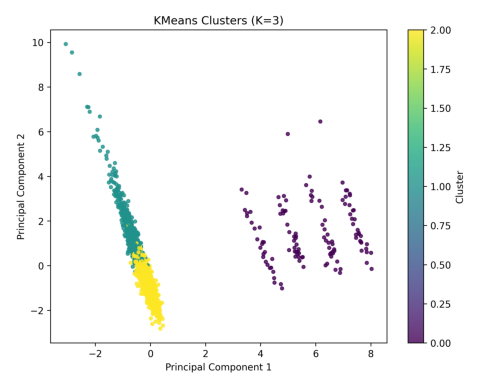

In [39]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("../results/kmeans/cluster_plot_k3.png")

plt.imshow(img)
plt.axis("off")
plt.show()

In [30]:
import numpy as np

unique, counts = np.unique(kmeans.labels, return_counts=True)
cluster_sizes = dict(zip(unique, counts))

cluster_sizes


{np.int32(0): np.int64(122),
 np.int32(1): np.int64(769),
 np.int32(2): np.int64(1621)}

In [31]:
cluster_variances = {}

for c in np.unique(kmeans.labels):
    points = X_pca[kmeans.labels == c]
    var = np.mean(np.var(points, axis=0))
    cluster_variances[c] = var

cluster_variances


{np.int32(0): np.float64(0.986789163245568),
 np.int32(1): np.float64(0.899962761632634),
 np.int32(2): np.float64(0.7673293076645359)}

In [36]:
import pandas as pd
import numpy as np

# Distance from centroid (already computed earlier)
centroids = kmeans.model.cluster_centers_
distances = np.linalg.norm(X_pca - centroids[kmeans.labels], axis=1)

# Build anomaly table
anomaly_df = pd.DataFrame({
    "cluster": kmeans.labels,
    "distance": distances
})

# Sort by anomaly score (largest distance = most anomalous)
top_anomalies = anomaly_df.sort_values("distance", ascending=False)

top_anomalies.head(15)


,cluster,distance
2273,1,14.751616
2191,1,13.206313
1459,1,11.545183
934,1,9.697714
311,1,9.489495
1258,1,9.348431
2382,1,9.279966
450,1,8.760566
274,0,8.066121
449,1,7.955668


## 📌 Combined Anomaly Analysis from KMeans

KMeans anomaly detection can be interpreted from two complementary perspectives:

1. **Cluster-level anomalies (density-based)**  
2. **Point-level anomalies (distance-based)**  

Using both gives a complete understanding of unusual behavior in the dataset.

---

## 1. Density-Based Anomaly Analysis (Cluster Size + Variance)

### Cluster Size
- **Cluster 0:** 122 points → rare behavior → high anomaly likelihood  
- **Cluster 1:** 769 points → medium frequency → medium anomaly likelihood  
- **Cluster 2:** 1621 points → common behavior → normal  

### Cluster Variance
- **Cluster 0:** 0.9867 → highest variance → unstable behavior  
- **Cluster 1:** 0.8999 → medium variance  
- **Cluster 2:** 0.7673 → lowest variance → stable behavior  

### Density-Based Interpretation
- **Cluster 0** is the **anomaly cluster** because it is both the smallest and the most dispersed.  
- **Cluster 1** contains borderline anomalies.  
- **Cluster 2** represents normal, low‑risk behavior.

This shows that KMeans successfully separates normal, irregular, and anomalous behavior based on cluster density, size, and variance.

---

## 2. Distance-Based Anomaly Analysis (Point-Level Outliers)

Anomaly scores were computed using the Euclidean distance from each point to its assigned centroid.  
Larger distances indicate more unusual behavior.

### Findings from Distance Ranking
- The **highest anomaly scores** come from points in **Cluster 1** (distance > 10).  
  These are extreme deviations from typical behavior within that cluster.
- **Cluster 0** contains **consistent but moderate anomalies**, which aligns with it being the rare and unstable cluster.
- **Cluster 2** contains **no high-distance points**, confirming it represents normal behavior.

### Distance-Based Interpretation
- **Cluster 1** contains the **most extreme individual anomalies**.  
- **Cluster 0** contains **many moderate anomalies** due to its instability.  
- **Cluster 2** contains **normal, low-risk points**.

---

## ⭐ Final Combined Interpretation

- **Cluster 0** is the **overall anomaly cluster** (rare + high variance).  
- **Cluster 1** contains the **most extreme individual outliers** (largest distances).  
- **Cluster 2** is the **normal cluster** (large + stable).  

This combined analysis shows that:
- Cluster 0 represents a rare and unstable behavioral pattern.  
- Cluster 1 includes a few extremely unusual points that stand out even more than those in Cluster 0.  
- Cluster 2 represents stable, low-risk behavior.

Using both density-based and distance-based methods provides a complete and reliable anomaly detection framework.
